# Project 1 Part 2 by Prathamesh Uravane 



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import  LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score,confusion_matrix
import random
from tqdm.auto  import tqdm
pd.set_option("display.max_colwidth", None)

In [2]:
#Import data
df=pd.read_csv('DiabetesData.csv')

In [3]:
df.head()

,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
0,215,5.7,7.9,7.9,30.5,0.89,134,78,41,160,145,136,236,6.36,8.18,29.6,1
1,143,6.7,6.5,8.7,23.1,0.80,129,76,55,50,30,93,150,2.00,5.63,23.0,0
2,57,6.4,10.0,8.1,22.2,0.81,115,73,66,99,36,118,195,5.07,7.51,44.7,1
3,49,3.4,6.6,5.2,26.8,0.88,120,93,50,79,140,139,253,5.28,9.03,38.2,1
4,109,7.2,7.4,5.0,21.2,0.78,92,67,52,125,160,137,184,12.74,7.20,23.5,1


In [4]:
df.nunique()

physical_activity_minutes_per_week     620
diet_score                             101
sleep_hours_per_day                     71
screen_time_hours_per_day              156
bmi                                    240
waist_to_hip_ratio                      40
systolic_bp                             86
diastolic_bp                            60
hdl_cholesterol                         79
ldl_cholesterol                        190
triglycerides                          262
glucose_fasting                        109
glucose_postprandial                   210
insulin_level                         2350
hba1c                                  548
diabetes_risk_score                    569
diagnosed_diabetes                       2
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   physical_activity_minutes_per_week  100000 non-null  int64  
 1   diet_score                          100000 non-null  float64
 2   sleep_hours_per_day                 100000 non-null  float64
 3   screen_time_hours_per_day           100000 non-null  float64
 4   bmi                                 100000 non-null  float64
 5   waist_to_hip_ratio                  100000 non-null  float64
 6   systolic_bp                         100000 non-null  int64  
 7   diastolic_bp                        100000 non-null  int64  
 8   hdl_cholesterol                     100000 non-null  int64  
 9   ldl_cholesterol                     100000 non-null  int64  
 10  triglycerides                       100000 non-null  int64  
 11  glucose_fasting            

In [6]:
df.describe(include='all')

,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,118.911640,5.994787,6.997818,5.996468,25.612653,0.856078,115.799610,75.23249,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,84.409662,1.780954,1.094622,2.468406,3.586705,0.046837,14.284073,8.20425,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,0.000000,0.000000,3.000000,0.500000,15.000000,0.670000,90.000000,50.00000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,57.000000,4.800000,6.300000,4.300000,23.200000,0.820000,106.000000,70.00000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,100.000000,6.000000,7.000000,6.000000,25.600000,0.860000,116.000000,75.00000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,160.000000,7.200000,7.700000,7.700000,28.000000,0.890000,125.000000,81.00000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,833.000000,10.000000,10.000000,16.800000,39.200000,1.060000,179.000000,110.00000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [7]:
#labels
y=df['diagnosed_diabetes']
y.unique()

array([1, 0], dtype=int64)

Text(0.5, 1.0, 'diagnosed_diabetes')

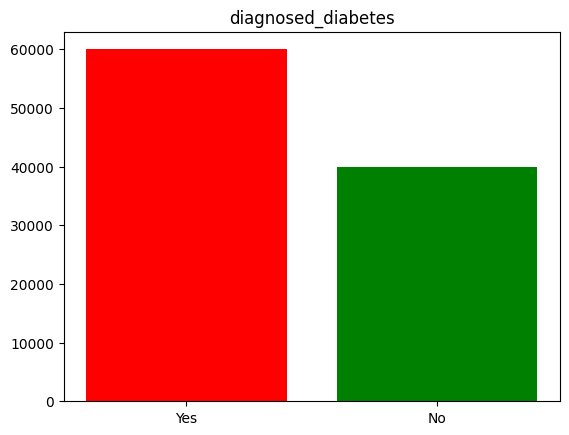

In [8]:
plt.bar(['Yes', 'No'],[len(y[y==1]),len(y[y==0])],color=['red','green'])
plt.title('diagnosed_diabetes')

In [9]:
#Labels
X=df.drop(columns='diagnosed_diabetes')
y=df['diagnosed_diabetes']


In [10]:
print("X shape",X.shape)
print("y shape",y.shape)

X shape (100000, 16)
y shape (100000,)


## Task 3

In [11]:
# Initialize accuracy trackers
results = {
    'KNN': [],
    'NB_Multi': [],
    'LR': [],
    'NB_Guass': [],
    'SVC': []
}

In [12]:
from tqdm.auto  import tqdm
for i in tqdm(range(20)):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=None)  #train test split
    for k in tqdm(range(3,21, 1)):
        knn_classifier=KNeighborsClassifier(n_neighbors=k)
        knn_classifier.fit(X_train,y_train)
        y_pred=knn_classifier.predict(X_test)
        accuracy=accuracy_score(y_test,y_pred)
        results['KNN'].append([i,k,accuracy])

    # Multinomial Naïve Bayes assumes categories follow multinomial distribution
    nb_multi = MultinomialNB()
    nb_multi.fit(X_train, y_train)
    multi_preds = nb_multi.predict(X_test)
    accuracy=accuracy_score(y_test,multi_preds)
    results['NB_Multi'].append([i,accuracy])

    # Gaussian Naïve Bayes assumes categories follow normal distribution 
    nb_gauss = GaussianNB()
    nb_gauss.fit(X_train, y_train)
    gauss_preds = nb_gauss.predict(X_test)
    accuracy=accuracy_score(y_test,gauss_preds)
    results['NB_Guass'].append([i,accuracy])
    
    # Logistic Regression
    LR = LogisticRegression(solver='lbfgs')
    LR.fit(X_train, y_train)
    lr_preds = LR.predict(X_test)
    accuracy=accuracy_score(y_test,lr_preds)
    results['LR'].append([i,accuracy])
    
    # Linear SVC 
    SVC = LinearSVC(C=1)# lambda value 1
    SVC.fit(X_train, y_train)
    y_pred = SVC.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    results['SVC'].append([i,accuracy])

  

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  0%|          | 0/18 [00:00<?, ?it/s]

C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


...

C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  0%|          | 0/18 [00:00<?, ?it/s]

C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  0%|          | 0/18 [00:00<?, ?it/s]

C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [13]:
Knn_results=results['KNN']
results_other=results.pop('KNN')

In [14]:
#Convert results in DF for easy plotting 
Knn_results_df=pd.DataFrame(Knn_results,columns=['i','k','accuracy'])
Knn_results_df.describe(include='all')

,i,k,accuracy
count,360.000000,360.000000,360.000000
mean,9.500000,11.500000,0.825823
std,5.774307,5.195348,0.009514
min,0.000000,3.000000,0.796720
25%,4.750000,7.000000,0.822100
50%,9.500000,11.500000,0.829240
75%,14.250000,16.000000,0.832570
max,19.000000,20.000000,0.836680


 ### KNN avg accuracy 82.57%

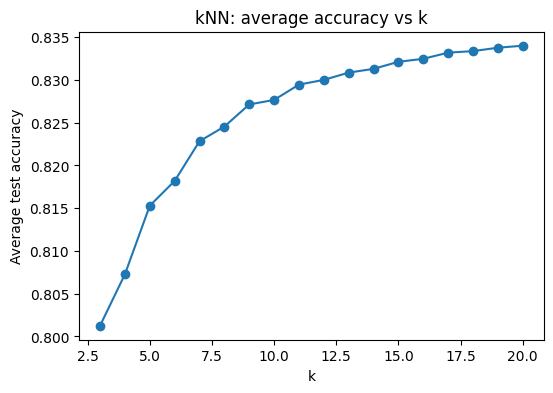

In [15]:
mean_acc = Knn_results_df.groupby('k', as_index=False)['accuracy'].mean()
plt.figure(figsize=(6,4))
plt.plot(mean_acc['k'], mean_acc['accuracy'], marker='o')
plt.xlabel('k'); plt.ylabel('Average test accuracy'); plt.title('kNN: average accuracy vs k')
plt.savefig("KNN avg test accuracy v k", dpi=300)
plt.show()


In [16]:
results_NBGuass=results['NB_Guass']
results_NBGuass=pd.DataFrame(results_NBGuass,columns=['i','accuracy'])
results_NBGuass.describe(include='all')

,i,accuracy
count,20.00000,20.000000
mean,9.50000,0.859836
std,5.91608,0.002018
min,0.00000,0.856480
25%,4.75000,0.858060
50%,9.50000,0.860180
75%,14.25000,0.861160
max,19.00000,0.863400


### Gaussion Naive Bayes avg accuracy = 86%

In [17]:
results_NB_Multi=results['NB_Multi']
results_NB_Multi=pd.DataFrame(results_NB_Multi,columns=['i','accuracy'])
results_NB_Multi.describe(include='all')

,i,accuracy
count,20.00000,20.000000
mean,9.50000,0.644930
std,5.91608,0.003406
min,0.00000,0.638960
25%,4.75000,0.642490
50%,9.50000,0.644460
75%,14.25000,0.647630
max,19.00000,0.651960


### Multinomial Naive Bayes avg accuracy= 64.61%

In [18]:
result_LR=results['LR']
result_LR=pd.DataFrame(result_LR,columns=['i','accuracy'])
result_LR.describe(include='all')

,i,accuracy
count,20.00000,20.000000
mean,9.50000,0.801070
std,5.91608,0.002567
min,0.00000,0.795680
25%,4.75000,0.799470
50%,9.50000,0.801320
75%,14.25000,0.802280
max,19.00000,0.806520


### Logistic Regression avg accuracy= 80.10%

In [19]:
result_SVC=results['SVC']
result_SVC=pd.DataFrame(result_SVC,columns=['i','accuracy'])
result_SVC.describe(include='all')

,i,accuracy
count,20.00000,20.000000
mean,9.50000,0.747276
std,5.91608,0.097920
min,0.00000,0.543760
25%,4.75000,0.666860
50%,9.50000,0.787520
75%,14.25000,0.825250
max,19.00000,0.850200


### Linear SVC avg accuracy= 74.40

## Task 4

In [20]:
 X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=None)  #train test split

In [21]:
p = X_train.shape[1]
p


16

In [22]:
X_train.head()

,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score
71462,145,4.4,7.5,3.0,26.5,0.91,119,70,48,127,170,108,198,15.33,7.43,24.6
6423,259,5.8,7.6,5.5,24.3,0.81,119,76,53,110,161,126,140,14.01,6.54,21.3
44016,120,5.4,7.6,6.4,32.8,0.93,90,77,65,100,212,90,196,10.27,7.22,21.4
12280,111,7.2,7.3,10.6,33.7,0.94,123,99,48,137,89,137,208,17.30,7.65,40.5
89316,191,5.9,6.2,9.8,31.5,0.92,106,80,57,115,109,99,162,16.08,5.97,30.2


In [23]:
knn_results=[]
NB_Multi_results=[]
NB_Guass_results=[]
LR_results=[]
SVC_results=[]

In [24]:
M=[3,7]
for m in M:
    for i in tqdm(range(100)):
        subset = random.sample(range(p), m) 
        subset_names = X_train.columns[subset]       # e.g. Index(['feat5','feat13','feat3'], dtype='object')

        Xtr_sub = X_train.loc[:, subset_names]
        Xte_sub = X_test.loc[:, subset_names]

        knn_classifier=KNeighborsClassifier(n_neighbors=11)
        knn_classifier.fit(Xtr_sub,y_train)
        y_pred=knn_classifier.predict(Xte_sub)
        accuracy=accuracy_score(y_test,y_pred)
        knn_results.append([m,i,subset_names,accuracy])

        # Multinomial Naïve Bayes assumes categories follow multinomial distribution
        nb_multi = MultinomialNB()
        nb_multi.fit(Xtr_sub, y_train)
        multi_preds = nb_multi.predict(Xte_sub)
        accuracy=accuracy_score(y_test,multi_preds)
        NB_Multi_results.append([m,i,subset_names,accuracy])

        # Gaussian Naïve Bayes assumes categories follow normal distribution 
        nb_gauss = GaussianNB()
        nb_gauss.fit(Xtr_sub, y_train)
        gauss_preds = nb_gauss.predict(Xte_sub)
        accuracy=accuracy_score(y_test,gauss_preds)
        NB_Guass_results.append([m,i,subset_names,accuracy])
        
         # Logistic Regression
        LR = LogisticRegression(solver='lbfgs')
        LR.fit(Xtr_sub, y_train)
        lr_preds = LR.predict(Xte_sub)
        accuracy=accuracy_score(y_test,lr_preds)
        LR_results.append([m,i,subset_names,accuracy])

        # Linear SVC 
        model = make_pipeline( LinearSVC(C=1))# lambda value 1
        model.fit(Xtr_sub, y_train)
        y_pred = model.predict(Xte_sub)
        accuracy=accuracy_score(y_test,y_pred)
        SVC_results.append([m,i,subset_names,accuracy])

'''
Note on SVM Implementation
Used Linear SVM with LinearSVC(C=1).
Chose linear kernel because data has 16 numeric features.
Linear model is fast, simple, and works well for this data.
C=1 gives a good balance between margin size and errors.
'''
  

  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from 

  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\upratham\anaconda3\envs\tf\lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\upratham\anaconda3\envs\tf\lib\site-p

'\nNote on SVM Implementation\nUsed Linear SVM with LinearSVC(C=1).\nChose linear kernel because data has 16 numeric features.\nLinear model is fast, simple, and works well for this data.\nC=1 gives a good balance between margin size and errors.\n'

In [25]:
knn_results=pd.DataFrame(knn_results,columns=['m','i','subset names','accuracy'])
NB_Multi_results=pd.DataFrame(NB_Multi_results,columns=['m','i','subset names','accuracy'])
NB_Guass_results=pd.DataFrame(NB_Guass_results,columns=['m','i','subset names','accuracy'])
LR_results=pd.DataFrame(LR_results,columns=['m','i','subset names','accuracy'])
SVC_results=pd.DataFrame(SVC_results,columns=['m','i','subset names','accuracy'])

In [26]:
results_clf = {
    "knn_results": knn_results,
    "NB_Multi_results": NB_Multi_results,
    "NB_Guass_results": NB_Guass_results,
    "LR_results": LR_results,
    "SVC_results": SVC_results
}


Classifier : knn_results m=3
Max Accuracy :  0.89676
Best subset : physical_activity_minutes_per_week, waist_to_hip_ratio, hba1c

Classifier : knn_results m=7
Max Accuracy :  0.83796
Best subset : screen_time_hours_per_day, glucose_postprandial, glucose_fasting, diet_score, hba1c, diabetes_risk_score, bmi




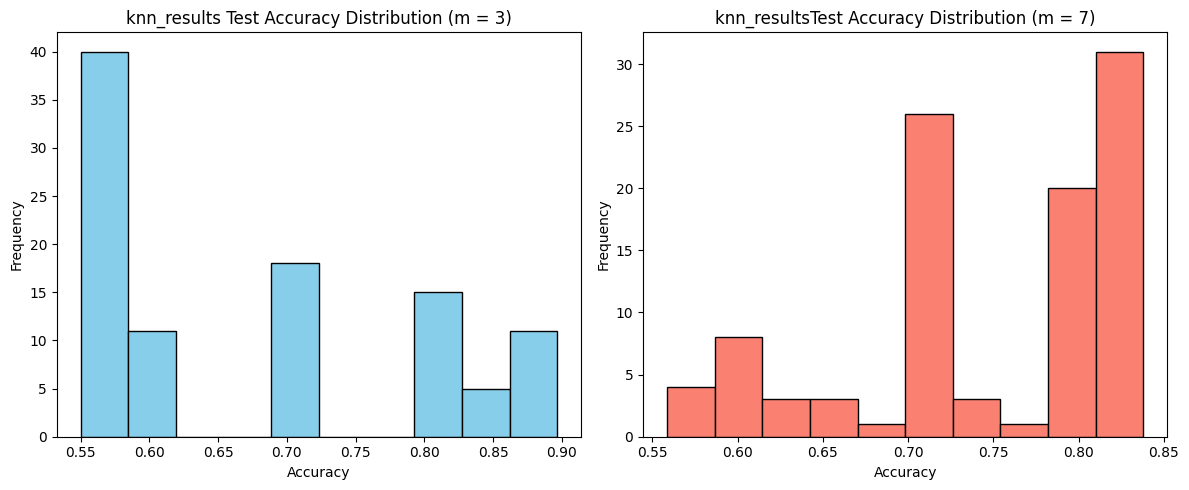


Classifier : NB_Multi_results m=3
Max Accuracy :  0.76452
Best subset : diastolic_bp, hdl_cholesterol, glucose_postprandial

Classifier : NB_Multi_results m=7
Max Accuracy :  0.77408
Best subset : waist_to_hip_ratio, diabetes_risk_score, screen_time_hours_per_day, glucose_postprandial, sleep_hours_per_day, diastolic_bp, systolic_bp




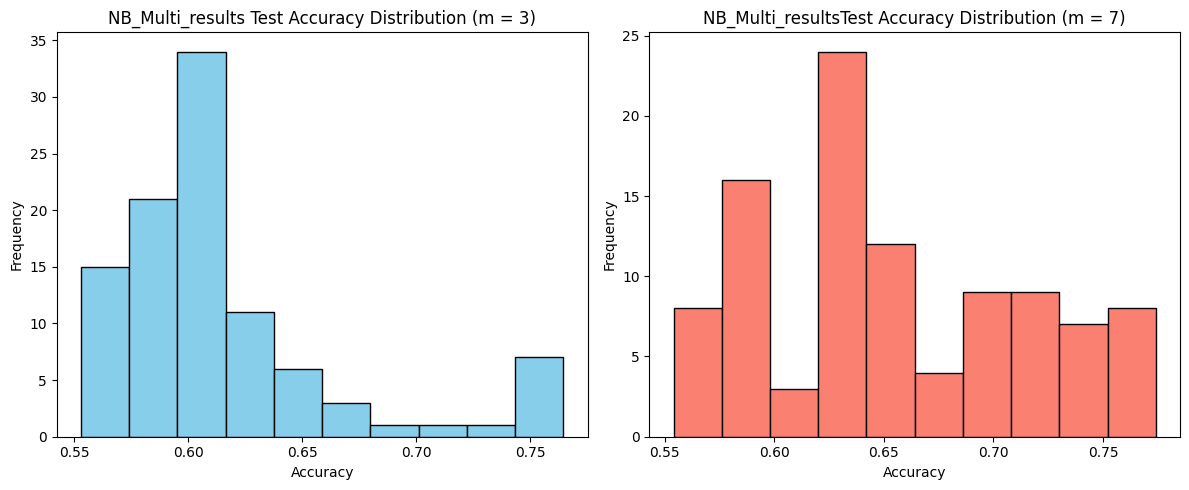


Classifier : NB_Guass_results m=3
Max Accuracy :  0.8648
Best subset : diastolic_bp, hba1c, diabetes_risk_score

Classifier : NB_Guass_results m=7
Max Accuracy :  0.86716
Best subset : glucose_fasting, waist_to_hip_ratio, hba1c, glucose_postprandial, diastolic_bp, systolic_bp, sleep_hours_per_day




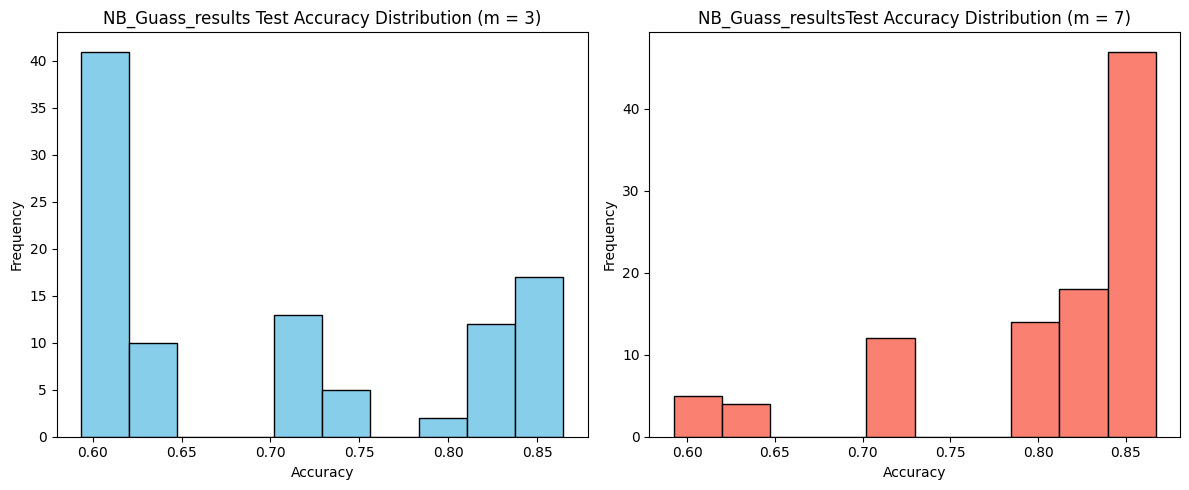


Classifier : LR_results m=3
Max Accuracy :  0.85484
Best subset : hba1c, glucose_fasting, bmi

Classifier : LR_results m=7
Max Accuracy :  0.8594
Best subset : ldl_cholesterol, hba1c, systolic_bp, diet_score, glucose_postprandial, insulin_level, glucose_fasting




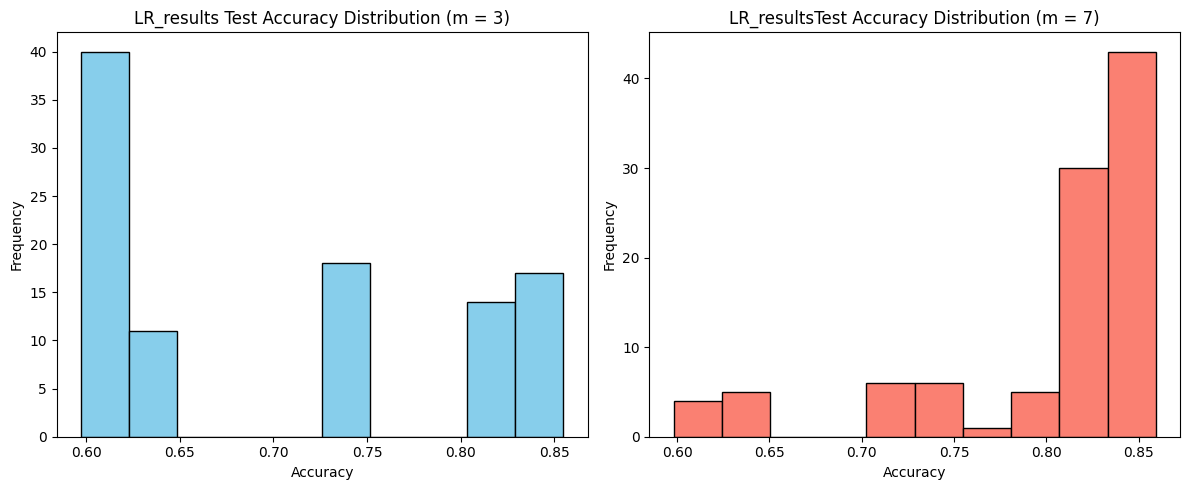


Classifier : SVC_results m=3
Max Accuracy :  0.89376
Best subset : hba1c, insulin_level, systolic_bp

Classifier : SVC_results m=7
Max Accuracy :  0.89252
Best subset : glucose_postprandial, sleep_hours_per_day, ldl_cholesterol, bmi, physical_activity_minutes_per_week, hba1c, diet_score




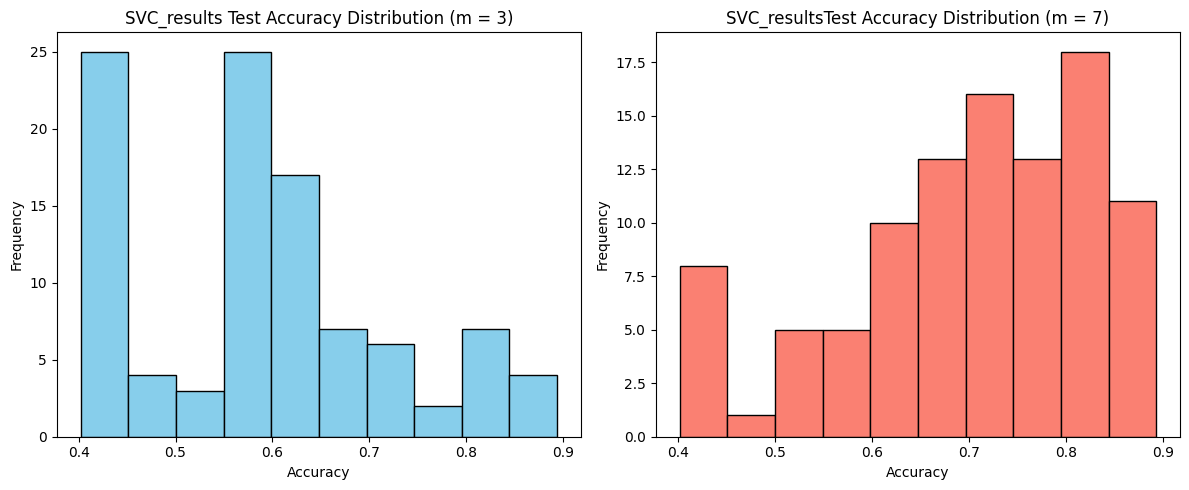

In [27]:
for name, c in results_clf.items():
    #c=pd.DataFrame(c,columns=['m','i','subset names','accuracy'])
    r_m_3 = c[c["m"] == 3]
    max_accuracy = r_m_3.loc[r_m_3["accuracy"].idxmax(),'accuracy']
    best_subset = r_m_3.loc[r_m_3["accuracy"].idxmax(), "subset names"]
    print('\nClassifier :',name,'m=3')
    print('Max Accuracy : ',max_accuracy)
    print('Best subset :',", ".join(best_subset))
    r_m_7 = c[c["m"] == 7]
    max_accuracy = r_m_7.loc[r_m_7["accuracy"].idxmax(),'accuracy']
    best_subset = r_m_7.loc[r_m_7["accuracy"].idxmax(), "subset names"]
    print('\nClassifier :',name,'m=7')
    print('Max Accuracy : ',max_accuracy)
    print('Best subset :',", ".join(best_subset))
    print('\n')
    

    plt.figure(figsize=(12, 5))

    # Histogram for m = 3
    plt.subplot(1, 2, 1)
    plt.hist(r_m_3["accuracy"], bins=10, color='skyblue', edgecolor='black')
    plt.title(f"{name} Test Accuracy Distribution (m = 3)")
    plt.xlabel("Accuracy")
    plt.ylabel("Frequency")
  

    # Histogram for m = 7
    plt.subplot(1, 2, 2)
    plt.hist(r_m_7["accuracy"], bins=10, color='salmon', edgecolor='black')
    plt.title(f"{name}Test Accuracy Distribution (m = 7)")
    plt.xlabel("Accuracy")
    plt.ylabel("Frequency")
    plt.savefig(f"{name} accuracy.png", dpi=300)

    plt.tight_layout()
    plt.show()

